# Bài toán Dự đoán số lượng bán ra của các sản phẩm trên nền tảng thương mại điện tử tiki
---
**Trường**: Đại học Sài Gòn<p>
**Môn học**: Khai phá dữ liệu và ứng dụng


## Cài đặt môi trường

In [1]:
import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings

pd.set_option('display.max_columns', 30)
sns.set_style("ticks")
sns.set_palette("pastel")

warnings.filterwarnings("ignore", category=FutureWarning)

## Tải dữ liệu

### Mô tả thuộc tính

* id: ID sản phẩm
* name: tiêu đề sản phẩm
* description: mô tả sản phẩm
* original_price: giá gốc (chưa giảm giá)
* price: giá bán (đã áp dụng giảm giá)
* fulfillment_type: dropship / seller_delivery / tiki_delivery.
  * Dropship products go from (seller - TIKI warehouse - customers), packaging by TIKI.
  * seller_delivery products go from (seller - customers) directly, packaging by sellers.
  * tiki_delivery TIKI-self-owned products go from (TIKI warehouse - customers)
* brand: OEM or registered brands. OEM means original equiment manufacturer or briefly 'no brand'.
* review_counts: số lượng đánh giá
* rating_average: xếp hạng trung bình của sản phẩm (0 - ⭐⭐⭐⭐⭐)
* favorite_count: số lượng người dùng thêm sản phẩm vào mục yêu thích của họ
* pay_later: cho phép mua hàng trả sau (bằng ví trả sau)
* current_seller: tên của người bán
* date_created: số ngày kể từ khi tạo sản phẩm đến lần cuối update (13/09/2023) 
* number_of_images: số lượng hình ảnh về sản phẩm
* vnd_cashback: số tiền được hoàn lại khi mua sản phẩm (VNĐ)
* has_video: đúng nếu sản phẩm có video
* quantity_sold: tổng số lượt bán của sản phẩm

In [2]:
men_shoes = pd.read_csv('/kaggle/input/datasets/michaelminhpham/vietnamese-tiki-e-commerce-dataset/vietnamese_tiki_products_men_shoes.csv')
women_shoes = pd.read_csv('/kaggle/input/datasets/michaelminhpham/vietnamese-tiki-e-commerce-dataset/vietnamese_tiki_products_women_shoes.csv')

men_shoes = men_shoes.drop(columns=['Unnamed: 0'])
women_shoes = women_shoes.drop(columns=['Unnamed: 0'])

Tạo thêm thuộc tính `category` và gắn giá trị `men` hoặc `women` ứng với mỗi dataset

Nối 2 tệp dữ liệu lại với nhau để được tệp dữ liệu duy nhất chứa thông tin giày dép của cả nam nữ

In [3]:
men_shoes['category'] = 'men'
women_shoes['category'] = 'women'

In [4]:
shoes = pd.concat([men_shoes, women_shoes])
shoes = shoes.reset_index().drop(columns='index')
shoes = shoes.drop_duplicates(subset=['id'])

### Tổng quan dữ liệu

In [5]:
shoes.sample(5)

,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
4553,217413551,Giày Palladium Pampa Hi Htg Supply 77356-797-M,Là thương hiệu luôn đồng hành cùng những nhà t...,2000000,2000000,dropship,Palladium,0,0.0,0,True,Sneaker Buzz,215,6,0,False,men,0
9719,47239390,Giày lười nữ TT-1700020,Là một sản phẩm được thiết kế vừa trẻ trung ti...,370000,370000,dropship,OEM,0,0.0,0,True,Giày Thủy Tinh,1337,1,0,False,women,1
5156,208405200,Bộ vệ sinh giày Sneaker Thecobbler cao cấp * ...,Chai làm sạch giày dạng bọt Thecobbler Foam Cl...,180000,180000,dropship,OEM,0,0.0,0,True,Thecobbler Sneaker Protection,278,6,24094,True,men,2
4055,109787039,Giày tây nam đục lỗ 20889,Đặc trưng giày tây nam đục lỗ Những đ...,374500,336900,dropship,OEM,0,0.0,0,True,ĐỒ DA THÀNH LONG TLG,801,9,9019,False,men,0
11159,179747877,bộ 2 miếng dán đế giày dép chống trơn trượt -N...,- Chất liệu: nhựa dập vân hình thoi quả...,6900,6900,dropship,OEM,0,0.0,0,False,hotdeal365,488,6,0,False,women,6


In [6]:
shoes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11661 entries, 0 to 11663
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                11661 non-null  int64  
 1   name              11661 non-null  object 
 2   description       11661 non-null  object 
 3   original_price    11661 non-null  int64  
 4   price             11661 non-null  int64  
 5   fulfillment_type  11660 non-null  object 
 6   brand             11661 non-null  object 
 7   review_count      11661 non-null  int64  
 8   rating_average    11661 non-null  float64
 9   favourite_count   11661 non-null  int64  
 10  pay_later         11661 non-null  bool   
 11  current_seller    11661 non-null  object 
 12  date_created      11661 non-null  int64  
 13  number_of_images  11661 non-null  int64  
 14  vnd_cashback      11661 non-null  int64  
 15  has_video         11661 non-null  bool   
 16  category          11661 non-null  object 
 17

In [7]:
shoes.describe().T

,count,mean,std,min,25%,50%,75%,max
id,11661.0,1.508708e+08,6.236177e+07,159901.0,108035520.0,158757098.0,196782467.0,263117023.0
original_price,11661.0,3.696097e+05,6.537084e+05,1000.0,79000.0,180000.0,380000.0,14700000.0
price,11661.0,3.276346e+05,5.842968e+05,1000.0,75000.0,169000.0,305000.0,14700000.0
review_count,11661.0,3.866650e+00,2.130257e+01,0.0,0.0,0.0,2.0,969.0
rating_average,11661.0,1.628008e+00,2.191028e+00,0.0,0.0,0.0,4.5,5.0
favourite_count,11661.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0
date_created,11661.0,6.313369e+02,3.661468e+02,0.0,365.0,580.0,810.0,2889.0
number_of_images,11661.0,6.061744e+00,2.984976e+00,1.0,4.0,6.0,8.0,32.0
vnd_cashback,11661.0,1.791002e+03,8.550901e+03,0.0,0.0,0.0,0.0,167720.0
quantity_sold,11661.0,1.941394e+01,1.393103e+02,0.0,0.0,1.0,6.0,9245.0


## TIền xử lí dữ liệu

### Loại bỏ dữ liệu không cần thiết

Thông qua quá trình nghiên cứu dữ liệu, nhóm nhận ra các sản phẩm được gắn nhãn `shoe` để tiện cho việc tìm kiếm trên nền tảng tiki. Thực chất trong danh mục giày dép còn có cả các phụ kiện (sticker, dây giày, tất...) và sản phẩm chăm sóc, vệ sinh giày dép (xịt khử mùi, xi đánh giày...).

Vì vậy, việc cần làm trước tiên là lọc bớt các sản phẩm không phải giày dép.

In [8]:

# 1. Keyword giày dép
shoe_keywords = [
    "giày", "dép", "sandal", "sandals", "sandan",
    "sneaker", "guốc", "xục", "boots"
]

# 2. Keyword phụ kiện, sản phẩm khác
noise_keywords = [
    "dây giày", "lót", "cặp", "miếng", "độn", "nút gắn", "lò xo", "nẹp", "kẹp xỏ giày",
    "xi", "đánh giày", "tẩy", "chai tẩy", "xịt", "khử mùi",
    "vệ sinh", "phục hồi", "dung dịch", "kit",
    "áo", "mũ", "ghế", "hộp", "hộp giày", "đựng giày", "hộp dép", "chai",
    "treo", "bàn chải", "giặt", "sáp", "stick", "sticker",
    "quai giày", "lắc", "chỉnh hình", "giấy", "lau",
    "hút ẩm", "gôm", "jibit", "keo", "khăn", "bọc", "cọ", "bút",
    "vớ", "tất", "combo"
]

# 3. Regex
pattern_shoe = r'\b(?:' + '|'.join(map(re.escape, shoe_keywords)) + r')\b'
pattern_noise = r'\b(?:' + '|'.join(map(re.escape, noise_keywords)) + r')\b'

# 4. Mask
mask_shoe = shoes['name'].str.lower().str.contains(pattern_shoe, na=False)
df_filtered = shoes[mask_shoe]

mask_noise = df_filtered['name'].str.lower().str.contains(pattern_noise, na=False)
df_filtered = df_filtered[~mask_noise]

df_filtered[['id', 'name']]

,id,name
0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất..."
1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...
2,119214657,dép tổ ong huyền thoại full size
3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại
4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,..."
...,...,...
11247,164193300,Dép HM Cao Cấp Da Bò Đế Đúc Hàng Ful Box Bill ...
11266,150531082,Giày nữ cao gót phong cách hàn quốc 20592
11316,145248505,Giày Sục thể thao lưới siêu thoáng chân
11365,144705121,Giày nữ Thời Trang Vàng Bạc giày Cưới giày Cao...


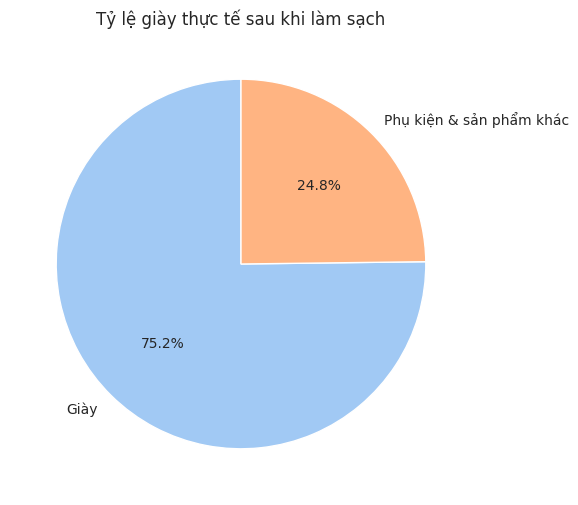

In [9]:
plt.figure(figsize=(6,6))
plt.pie([df_filtered.shape[0], shoes.shape[0] - df_filtered.shape[0]],
       labels=['Giày', 'Phụ kiện & sản phẩm khác'],
       autopct='%1.1f%%',
       startangle=90)
plt.title("Tỷ lệ giày thực tế sau khi làm sạch")
plt.show()

- Dữ liệu được làm sạch một cách mạnh tay
- Chấp nhận việc giảm dữ liệu hợp lệ để sạch hơn
- Có thể còn nhiễu do cách đặt tên đa dạng nhưng vẫn nằm trong mức chấp nhận được

In [10]:
shoes = df_filtered

### Xử lí nhiễu

Thuộc tính thương hiệu (`brand`) gặp phải lỗi định dạng, đôi khi sẽ dư dấu tab `\t`

In [11]:
shoes['brand'] = shoes['brand'].replace('\tOEM','OEM')

### Tạo các cột mới

Các cột bao gồm:
* **`has_rating`**: Giúp nhận biết sản phẩm có đánh giá hay không (nếu có đánh giá thì thấp nhất là 1 sao). Giúp mô hình học tốt hơn, sản phẩm không có đánh giá không hẳn sẽ tệ hơn sản phẩm 1*
* **`estimated_revenue`**: Doanh thu ước tính của sản phẩm = Giá hiện tại * Tổng số lượt bán (mang tính ước lượng vì giá bán thay đổi liên tục)
* ...

In [12]:

shoes['has_rating'] = shoes['rating_average'] > 0

shoes['estimated_revenue'] = shoes['price']*shoes['quantity_sold']

shoes['discount_rate'] = (shoes['original_price'] - shoes['price']) / shoes['original_price']

shoes['sales_per_day'] = shoes['quantity_sold'] / (shoes['date_created'] + 1)


In [13]:
shoes['sales_segment'] = pd.cut(shoes['quantity_sold'], bins=[0, 50, 500, 5000],
                                 labels=['Ít bán', 'Trung bình', 'Bán chạy'])

shoes['price_segment'] = pd.cut(shoes['price'], bins=[0, 200000, 500000, shoes['price'].max()], 
                 labels=['Bình dân', 'Tầm trung', 'Cao cấp'])

In [14]:
shoes.shape

(8769, 24)

In [15]:
shoes['has_video'] = shoes['has_video'].astype(int)

## Phân tích dữ liệu khám phá

In [16]:
shoes.describe().T

,count,mean,std,min,25%,50%,75%,max
id,8769.0,1.531271e+08,6.240213e+07,799279.0,109616785.0,1.601521e+08,1.987848e+08,2.631170e+08
original_price,8769.0,4.321361e+05,7.003408e+05,4000.0,118800.0,1.990000e+05,4.190000e+05,1.100000e+07
price,8769.0,3.810555e+05,6.216702e+05,4000.0,106750.0,1.990000e+05,3.500000e+05,1.100000e+07
review_count,8769.0,3.389668e+00,1.607389e+01,0.0,0.0,0.000000e+00,1.000000e+00,5.190000e+02
rating_average,8769.0,1.581492e+00,2.175359e+00,0.0,0.0,0.000000e+00,4.300000e+00,5.000000e+00
favourite_count,8769.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
date_created,8769.0,6.176387e+02,3.616411e+02,0.0,343.0,5.770000e+02,8.010000e+02,2.140000e+03
number_of_images,8769.0,6.062379e+00,3.007686e+00,1.0,4.0,6.000000e+00,8.000000e+00,3.200000e+01
vnd_cashback,8769.0,1.846878e+03,8.474169e+03,0.0,0.0,0.000000e+00,0.000000e+00,1.677200e+05
has_video,8769.0,8.758125e-02,2.827011e-01,0.0,0.0,0.000000e+00,0.000000e+00,1.000000e+00


favourite_count = 0 với mọi sản phẩm --> Không phân tích cột này

In [17]:
shoes.columns

Index(['id', 'name', 'description', 'original_price', 'price',
       'fulfillment_type', 'brand', 'review_count', 'rating_average',
       'favourite_count', 'pay_later', 'current_seller', 'date_created',
       'number_of_images', 'vnd_cashback', 'has_video', 'category',
       'quantity_sold', 'has_rating', 'estimated_revenue', 'discount_rate',
       'sales_per_day', 'sales_segment', 'price_segment'],
      dtype='object')

### Phân phối của biến mục tiêu

In [18]:
px.histogram(shoes,x='quantity_sold',nbins=30,marginal='box')

Dữ liệu lệch phải nặng

### Phân tích đơn biến

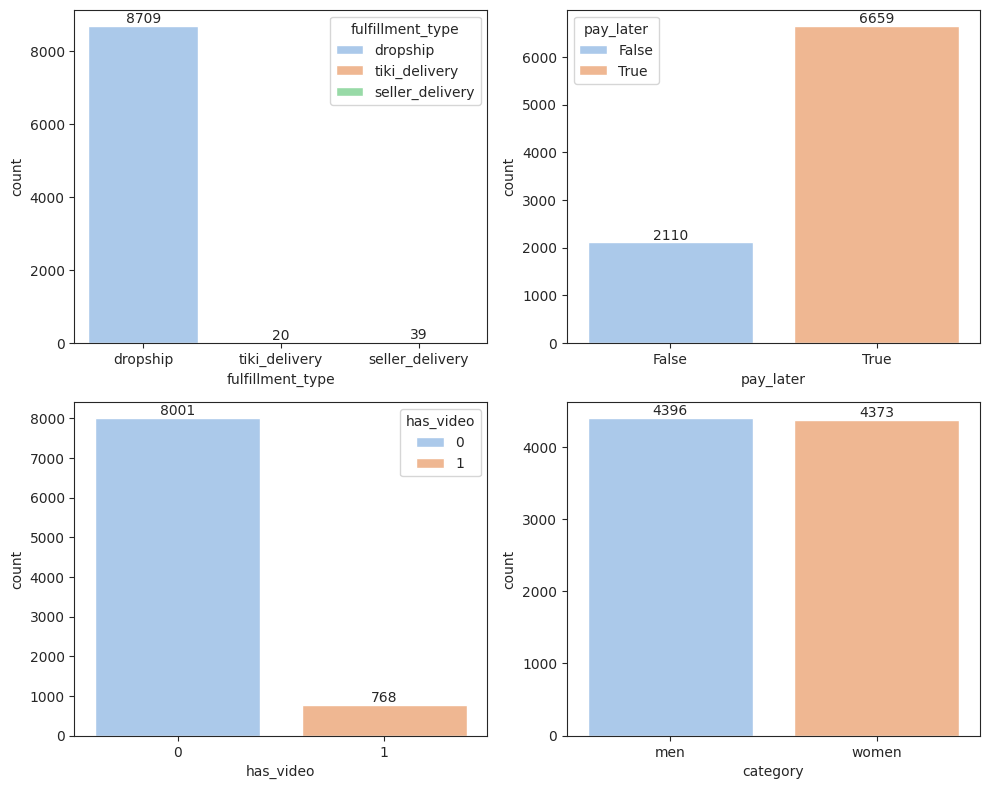

In [19]:
cat_cols = ['fulfillment_type', 'pay_later', 'has_video', 'category']
fig, axes = plt.subplots(figsize=(10, 8), nrows=2, ncols=2)

for col, ax in zip(cat_cols, axes.ravel()):
    sns.countplot(data=shoes, x=col, hue=col, ax=ax)
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()

* fulfillment_type: dropship là chủ yếu
* Phần lớn mặt hàng hỗ trợ trả sau (pay_later)
* Tỉ lệ sản phẩm cho nam và cho nữ khá cân bằng

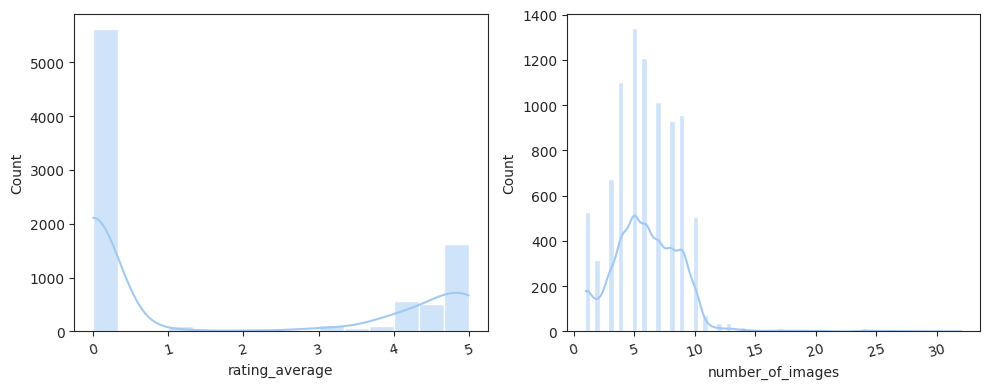

In [20]:
num_cols = ['rating_average', 'number_of_images']
fig, axes = plt.subplots(figsize=(10, 4), nrows=1, ncols=2)

for col, ax in zip(num_cols, axes.ravel()):
    sns.histplot(data=shoes, x=col, kde=True, ax=ax)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [21]:
px.histogram(shoes,x='price',nbins=20,marginal='box')

In [22]:
px.histogram(shoes,x='discount_rate',nbins=20,marginal='box')

In [23]:
px.histogram(shoes,x='vnd_cashback',nbins=20,marginal='rug')

In [24]:
px.histogram(shoes,x='date_created',nbins=20,marginal='box')

In [25]:
top_product_count_sellers = shoes['current_seller'].value_counts().nlargest(15)
fig = px.bar(top_product_count_sellers, x=top_product_count_sellers.index, y=top_product_count_sellers.values)
fig.update_layout(title='Top sellers with most count products')

In [26]:
top_revenue_sellers = shoes.groupby('current_seller')['estimated_revenue'].sum().nlargest(15)

fig = px.bar(top_revenue_sellers, x=top_revenue_sellers.index, y='estimated_revenue')
fig.update_layout(title='Top Sellers by Estimated Revenue')
fig.show()

**NOTE**: Thêm phân tích quan hệ xếp hạng số lượng sản phẩm và xếp hạng tổng doanh thu của seller

### Phân tích đa biến

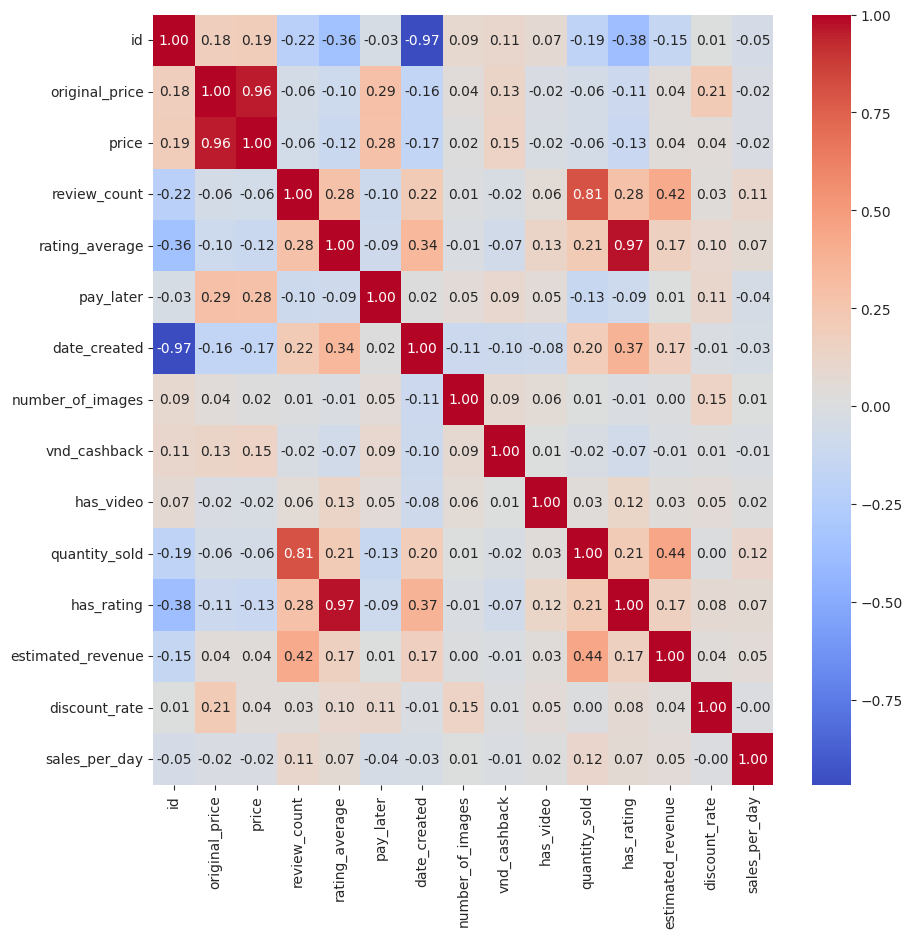

In [27]:
corr = shoes.drop(columns='favourite_count').corr(numeric_only=True)

plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

### Khám phá dữ liệu

<h4> Phân tích ảnh hưởng của video tới số lượng bán ra của sản phẩm </h4>

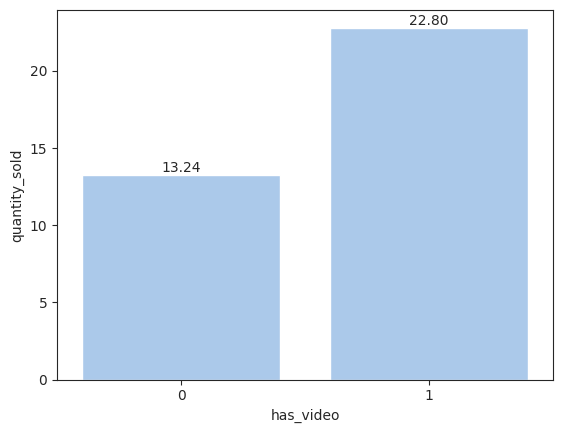

In [28]:
ax = sns.barplot(data=shoes, x='has_video', y='quantity_sold', estimator=np.mean, errorbar=None)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

Text(0, 0.5, 'quantity_sold_average')

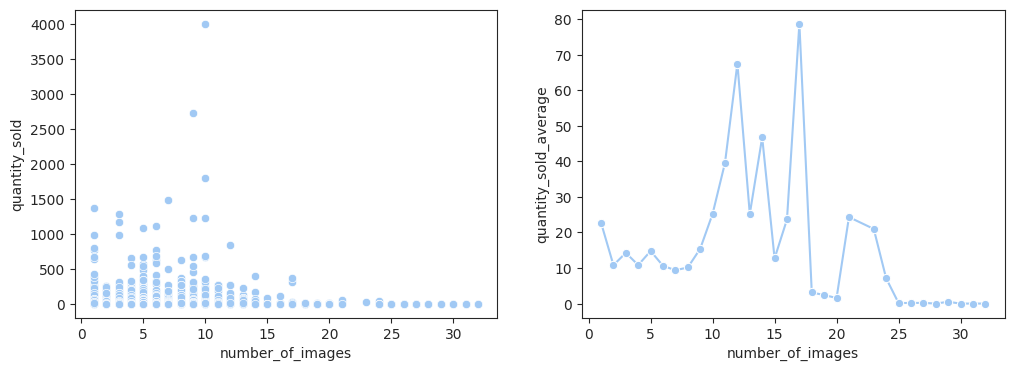

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=shoes, x='number_of_images', y='quantity_sold', ax=axes[0])

sns.lineplot(data=shoes, x='number_of_images', y='quantity_sold', estimator=np.mean, errorbar=None, marker='o')
axes[1].set_ylabel('quantity_sold_average')

In [30]:
shoes[(shoes['number_of_images'] >= 25) & (shoes['quantity_sold'] == 0)][['id', 'name', 'price', 'discount_rate', 'brand', 'current_seller', 'has_video', 'category', 'number_of_images']]


,id,name,price,discount_rate,brand,current_seller,has_video,category,number_of_images
2144,112247857,"Dép nam xỏ ngón, dép kẹp, dép tông nam da bò c...",399000,0.333890,OEM,AFADA STORE,0,men,31
3793,193155671,Dép sục nam nữ thời trang phong cách Hàn Quốc ...,199000,0.395137,OEM,Mua Là Thích,0,men,26
8198,155367956,Giày công sở mũi vuông đế bệt cao cấp - GIAY....,479000,0.368906,OEM,FADA SHOP,0,women,26
8216,155315965,Giày công sở mũi vuông đế bệt cao cấp - GIAY....,479000,0.467186,OEM,AFADA STORE,0,women,26
8682,155341258,Giày búp bê mũi vuông thời trang cao cấp đế vu...,699000,0.222469,OEM,YEDASHOP,0,women,26
8683,155315307,Giày búp bê mũi vuông thời trang cao cấp đế vu...,599000,0.333704,OEM,AFADA STORE,0,women,26
8756,185967512,Giày quai ngang nữ giày sandals nữ dép quai hậ...,529000,0.337922,OEM,TDBOOK,0,women,25
8785,185862841,Giày quai ngang nữ giày sandals nữ dép quai hậ...,569000,0.430430,OEM,BABYLON STORE,0,women,32
8794,184495659,Giày quai ngang nữ giày sandals nữ dép quai hậ...,459000,0.425532,OEM,FADA SHOP,0,women,27
8801,185949539,Giày quai ngang nữ giày sandals nữ dép quai hậ...,529000,0.470470,OEM,STORE ĐỒ GỖ MINI,0,women,27


Có khá nhiều hình ảnh nhưng lượt bán không cao, nhìn vào dữ liệu các sản phẩm không bán được ta thấy:
* Phần lớn sản phẩm giày dép nữ
* Không có thương hiệu, không có video => độ tin cậy thấp
* Mức giá khá cao, mức giảm giá ảo (30-50%)

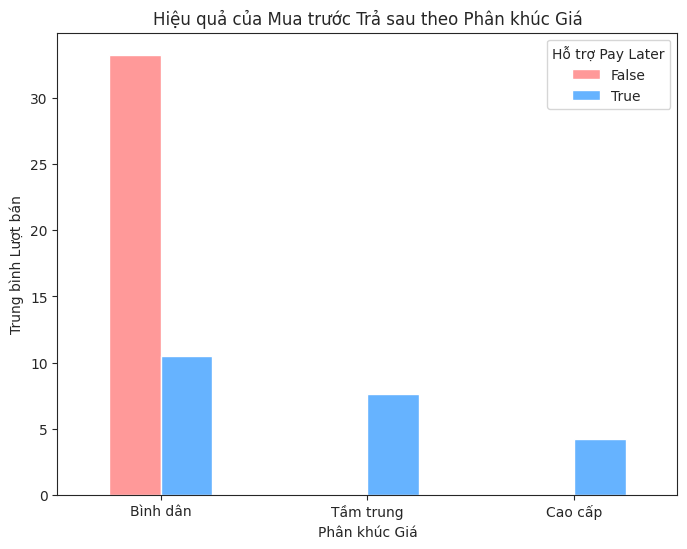

In [31]:
bins = [0, 200000, 500000, shoes['price'].max()]
labels = ['Bình dân', 'Tầm trung', 'Cao cấp']

pay_later_impact = (
    shoes.groupby(['price_segment', 'pay_later'], observed=True)['quantity_sold']
    .mean()
    .unstack()
)

# Vẽ biểu đồ
pay_later_impact.plot(kind='bar', figsize=(8, 6), color=['#ff9999', '#66b3ff'])
plt.title('Hiệu quả của Mua trước Trả sau theo Phân khúc Giá')
plt.xlabel('Phân khúc Giá')
plt.ylabel('Trung bình Lượt bán')
plt.legend(title='Hỗ trợ Pay Later')
plt.xticks(rotation=0)
plt.show()

Các sản phẩm không được hỗ trả sau chủ yếu là những sản phẩm giá rẻ, phân khúc bình dân

sales_segment
Ít bán        0.292326
Trung bình    0.246790
Bán chạy      0.177675
dtype: float64


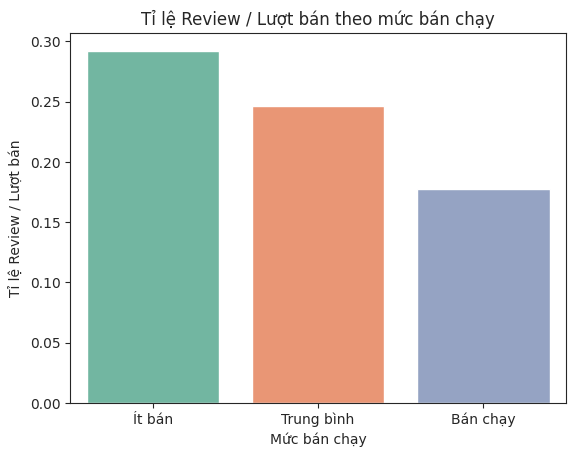

In [32]:
# Tính tỉ lệ review / lượt bán theo từng mức
ratio = shoes.groupby('sales_segment').apply(
    lambda df: (df['review_count'].sum() / df['quantity_sold'].sum())
)

print(ratio)

# Vẽ barplot
sns.barplot(x=ratio.index, y=ratio.values, palette="Set2")
plt.title("Tỉ lệ Review / Lượt bán theo mức bán chạy")
plt.xlabel("Mức bán chạy")
plt.ylabel("Tỉ lệ Review / Lượt bán")
plt.show()